# Phase 2 — Problem definition and data exploration

Reads `data/raw/` (phase 1's Overpass exports), cleans it, makes and
justifies the amenity weight / `max_distance_m` decisions, and writes
`data/processed/` — the small, committed GeoJSON that phase 3 (the
rule-based arm) and phase 4 (the LLM arm) both consume.

Research question and full phase plan: [`paper/PLAN.md`](../paper/PLAN.md).
The comparison metric this all eventually feeds:
[`paper/comparison_metric.md`](../paper/comparison_metric.md).

This notebook does **not** call `smart_spatial_system` — it only prepares
its inputs. No network, no LLM key needed (see `paper/PLAN.md`'s phase
table).


## Setup

In [21]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

# Vienna has no single EPSG:4326-friendly metric equivalent baked into
# smart_spatial_system's defaults, so we pick one explicitly. EPSG:31256
# (MGI / Austria GK East) is what smart_spatial_system's own example uses
# for Vienna (examples/accessibility_analysis.py) - meters, low distortion
# for the whole city. We only use it here to *sanity-check* geometry
# (areas, degenerate features); data/processed/ itself stays in WGS84
# (EPSG:4326), because build_accessibility_query_spec's own crs_transform
# step expects WGS84 input (its DEFAULT_SOURCE_CRS) and reprojects to
# whatever target_crs phase 3 passes it - reprojecting here too would be
# redundant and would drift out of sync if that default ever changes.
METRIC_CRS = "EPSG:31256"


## Load raw data

In [22]:
districts = gpd.read_file(RAW / "districts.geojson")
metro = gpd.read_file(RAW / "metro.geojson")
schools = gpd.read_file(RAW / "schools.geojson")
parks = gpd.read_file(RAW / "parks.geojson")

for name, gdf in [("districts", districts), ("metro", metro), ("schools", schools), ("parks", parks)]:
    # plain GeoJSON has no explicit CRS member (RFC 7946 assumes WGS84);
    # make that assumption explicit rather than silently relying on it.
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    print(f"{name:10s} n={len(gdf):4d}  crs={gdf.crs}  geom_types={gdf.geom_type.unique().tolist()}")


districts  n=  23  crs=EPSG:4326  geom_types=['Polygon']
metro      n= 109  crs=EPSG:4326  geom_types=['Point']
schools    n= 211  crs=EPSG:4326  geom_types=['Point']
parks      n=1063  crs=EPSG:4326  geom_types=['Polygon']


## Explore

Eyeball the four layers together before trusting them.

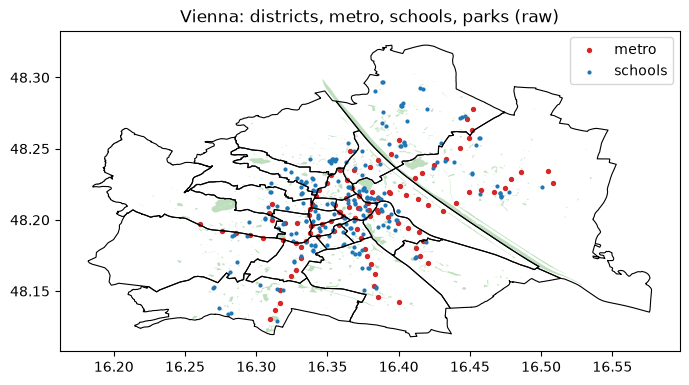

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
districts.boundary.plot(ax=ax, color="black", linewidth=0.8)
parks.plot(ax=ax, color="#7fbf7f", alpha=0.5, linewidth=0)
metro.plot(ax=ax, color="#d62728", markersize=8, label="metro")
schools.plot(ax=ax, color="#1f77b4", markersize=4, label="schools")
ax.set_title("Vienna: districts, metro, schools, parks (raw)")
ax.legend()
ax.set_aspect("equal")
plt.show()


In [24]:
# Quick property peek - useful for spotting missing/odd tags before we
# decide what to keep in data/processed/.
print("district tag columns:", sorted(districts.columns))
print()
print("schools missing name:", schools["name"].isna().sum(), "/", len(schools))
print("metro missing name:", metro["name"].isna().sum(), "/", len(metro))
print()
print("school isced:level value counts (if present):")
if "isced:level" in schools.columns:
    print(schools["isced:level"].value_counts(dropna=False))
else:
    print("  (tag not present on any school - Overpass export has no isced:level values)")


district tag columns: ['admin_level', 'admin_title', 'boundary', 'coat_of_arms', 'designation', 'geometry', 'name', 'name:de', 'name:en', 'name:etymology:wikidata', 'name:ru', 'name:uk', 'official_status', 'old_name', 'osm_id', 'osm_type', 'population', 'ref', 'ref:at:gkz', 'ref:at:okz', 'street_names:wikipedia', 'type', 'wikidata', 'wikipedia', 'wikipedia:ru']

schools missing name: 8 / 211
metro missing name: 0 / 109

school isced:level value counts (if present):
isced:level
NaN    209
1        1
2        1
Name: count, dtype: int64


**Decision — no school-type filtering.** `scripts/download_vienna_data.md`
left the school export unfiltered on purpose and flagged `isced:level` as
a possible restriction. We're not restricting: this case study scores
*general* accessibility to "a school", not a specific school type, and
narrowing by `isced:level` would mostly just shrink N for no benefit to
the reproducibility question this paper asks. Revisit only if the
advisor specifically wants e.g. primary-schools-only.


## Data cleaning

Drop anything geometrically broken before it corrupts every downstream distance/score.

In [25]:
def clean(gdf, name):
    before = len(gdf)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    dropped_null = before - len(gdf)

    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].make_valid()
    still_invalid = (~gdf.geometry.is_valid).sum()

    print(f"{name:10s} dropped_null_or_empty={dropped_null}  fixed_invalid={invalid.sum()}  still_invalid={still_invalid}")
    assert still_invalid == 0, f"{name}: {still_invalid} geometries still invalid after make_valid()"
    return gdf.reset_index(drop=True)

districts = clean(districts, "districts")
metro = clean(metro, "metro")
schools = clean(schools, "schools")
parks = clean(parks, "parks")

assert len(districts) == 23, f"expected 23 Vienna districts, got {len(districts)}"


districts  dropped_null_or_empty=0  fixed_invalid=0  still_invalid=0
metro      dropped_null_or_empty=0  fixed_invalid=0  still_invalid=0
schools    dropped_null_or_empty=0  fixed_invalid=0  still_invalid=0
parks      dropped_null_or_empty=0  fixed_invalid=0  still_invalid=0


### Reproject to a metric CRS to sanity-check geometry

Checking geometry *validity* doesn't strictly need a projected CRS
(`is_valid` is CRS-agnostic), but checking that areas/sizes are
*plausible* does - a degree-based "area" is meaningless. This is a
one-off check; nothing here is persisted in `METRIC_CRS`.


In [26]:
districts_m = districts.to_crs(METRIC_CRS)
parks_m = parks.to_crs(METRIC_CRS)

total_km2 = districts_m.geometry.area.sum() / 1e6
print(f"Vienna total area from district polygons: {total_km2:.1f} km2")
# Vienna's official area is ~414.6 km2 (Statistik Austria). Allow a modest
# margin - OSM boundary tracing vs. the official cadastre won't match to
# the decimal, but should be within a few percent.
assert 380 <= total_km2 <= 450, f"district area {total_km2:.1f} km2 is implausible for Vienna"

park_areas_ha = parks_m.geometry.area / 1e4
print(f"park areas (ha): min={park_areas_ha.min():.3f}  median={park_areas_ha.median():.3f}  max={park_areas_ha.max():.1f}")
# a handful of very large parks (Prater, Donaupark, Lainzer Tiergarten...)
# is expected; a *median* in the tens of km2 would signal a units bug.
assert park_areas_ha.max() < 5000, "a park bigger than 50 km2 almost certainly signals a geometry bug"


Vienna total area from district polygons: 414.9 km2
park areas (ha): min=0.001  median=0.295  max=397.5


### Reduce parks to Polygon -> Point (centroid)

`data/README.md` calls for this: amenity accessibility here is "nearest amenity", which needs point geometry, not polygon.

In [27]:
# Centroid in a projected (metric) CRS, then back to WGS84 for storage -
# taking a centroid directly in lon/lat distorts it for anything but the
# smallest, most circular polygons.
parks_pts = parks.copy()
parks_pts["area_m2"] = parks_m.geometry.area.values
parks_pts["geometry"] = parks_m.geometry.centroid.to_crs(4326).values
parks_pts = parks_pts.set_crs(4326, allow_override=True)

# sanity check: every centroid should land inside (or very near) Vienna's
# overall extent - a wildly off centroid would mean the reprojection or
# the centroid step above silently broke.
minx, miny, maxx, maxy = districts.total_bounds
pad = 0.02  # ~2km in degrees at this latitude - generous slack for edge parks
outside = ~parks_pts.geometry.x.between(minx - pad, maxx + pad) | ~parks_pts.geometry.y.between(miny - pad, maxy + pad)
assert outside.sum() == 0, f"{outside.sum()} park centroids fall outside Vienna's extent"
print(f"{len(parks_pts)} park centroids computed, all within Vienna's extent (+/- {pad} deg)")


1063 park centroids computed, all within Vienna's extent (+/- 0.02 deg)


## Problem definition: amenities, weights, `max_distance_m`

Per `paper/PLAN.md`, this is a modeling decision made *here*, not assumed.
All three follow a walkable "15-minute city" framing (Moreno et al.) —
short, brisk-walk cutoffs, not driving distances:

| Amenity | `max_distance_m` | weight | rationale |
|---|---|---|---|
| Metro (U-Bahn) | 800 | 3.0 | ~10 min walk; direct link to the whole public-transit network, so weighted highest and cut off shortest - beyond ~800m people typically use a bus/tram feeder instead of walking. |
| Schools | 1000 | 2.0 | ~12-13 min walk; a mid-range everyday-errand distance, medium importance for a household accessibility score. |
| Parks | 1500 | 1.0 | ~18-19 min walk; recreational green space is valuable but the most walkable-tolerant and least "essential", so it gets the lowest weight and the longest cutoff (people walk further for a park than for transit or school drop-off). |

This ordering (metro: highest weight/shortest cutoff; schools: medium;
parks: lowest weight/longest cutoff) matches `paper/PLAN.md`'s framing
verbatim - it is not re-derived per notebook, per `CLAUDE.md`.

`distance_field` names below must be unique (`smart_spatial_system`'s
`AmenitySpec` requires this, so the chained nearest-neighbor operations
don't silently overwrite each other's output column).


In [28]:
AMENITY_SPECS = [
    {"ref": "metro",   "distance_field": "distance_to_metro_m",   "max_distance_m": 800.0,  "weight": 3.0, "label": "Metro (U-Bahn) station"},
    {"ref": "schools", "distance_field": "distance_to_school_m",  "max_distance_m": 1000.0, "weight": 2.0, "label": "School"},
    {"ref": "parks",   "distance_field": "distance_to_park_m",    "max_distance_m": 1500.0, "weight": 1.0, "label": "Park"},
]
pd.DataFrame(AMENITY_SPECS)


,ref,distance_field,max_distance_m,weight,label
0,metro,distance_to_metro_m,800.0,3.0,Metro (U-Bahn) station
1,schools,distance_to_school_m,1000.0,2.0,School
2,parks,distance_to_park_m,1500.0,1.0,Park


## Trim fields and write `data/processed/`

Keep only what the analysis (or a curious reader) needs — this is meant
to stay "small, derived GeoJSON" per `README.md`'s structure section, not
a re-export of every OSM tag.


In [29]:
districts_out = districts[["osm_id", "ref", "name", "name:de", "population", "geometry"]].copy()
districts_out["area_km2"] = (districts_m.geometry.area / 1e6).round(3).values
districts_out["ref"] = districts_out["ref"].astype(int)
# left as float64, not a nullable Int64 - some GeoJSON drivers round-trip
# pandas' nullable Int64 NA handling oddly; population is metadata here,
# not something the scoring math consumes, so plain float is fine.
districts_out["population"] = pd.to_numeric(districts_out["population"], errors="coerce")
districts_out = districts_out.sort_values("ref").reset_index(drop=True)

metro_out = metro[["osm_id", "name", "geometry"]].copy()
schools_out = schools[["osm_id", "name", "geometry"]].copy()
parks_out = parks_pts[["osm_id", "name", "area_m2", "geometry"]].copy()
parks_out["area_m2"] = parks_out["area_m2"].round(1)

outputs = {
    "districts.geojson": districts_out,
    "metro.geojson": metro_out,
    "schools.geojson": schools_out,
    "parks.geojson": parks_out,
}
for filename, gdf in outputs.items():
    assert gdf.crs is not None and gdf.crs.to_epsg() == 4326, f"{filename}: expected EPSG:4326, got {gdf.crs}"
    path = PROCESSED / filename
    gdf.to_file(path, driver="GeoJSON")
    print(f"wrote {path}  ({len(gdf)} features, {path.stat().st_size / 1024:.1f} KB)")

specs_path = PROCESSED / "amenity_specs.json"
specs_path.write_text(json.dumps(AMENITY_SPECS, indent=2))
print(f"wrote {specs_path}")


wrote ../data/processed/districts.geojson  (23 features, 276.3 KB)
wrote ../data/processed/metro.geojson  (109 features, 17.6 KB)
wrote ../data/processed/schools.geojson  (211 features, 36.3 KB)
wrote ../data/processed/parks.geojson  (1063 features, 201.4 KB)
wrote ../data/processed/amenity_specs.json


## Final checks

Re-read what was just written - the on-disk files are what phase 3 actually depends on, not the in-memory GeoDataFrames above.

In [30]:
districts_check = gpd.read_file(PROCESSED / "districts.geojson")
metro_check = gpd.read_file(PROCESSED / "metro.geojson")
schools_check = gpd.read_file(PROCESSED / "schools.geojson")
parks_check = gpd.read_file(PROCESSED / "parks.geojson")
specs_check = json.loads((PROCESSED / "amenity_specs.json").read_text())

assert len(districts_check) == 23
assert set(districts_check["ref"]) == set(range(1, 24)), "district refs should be exactly 1..23"
assert (districts_check.geom_type == "Polygon").all()
assert (metro_check.geom_type == "Point").all()
assert (schools_check.geom_type == "Point").all()
assert (parks_check.geom_type == "Point").all(), "parks must be centroids (Point) by this point, not Polygon"
assert {s["ref"] for s in specs_check} == {"metro", "schools", "parks"}
for gdf in (districts_check, metro_check, schools_check, parks_check):
    assert gdf.geometry.notna().all() and (~gdf.geometry.is_empty).all()

print("all checks passed")
print()
print(pd.DataFrame({
    "layer": ["districts", "metro", "schools", "parks"],
    "n_features": [len(districts_check), len(metro_check), len(schools_check), len(parks_check)],
    "geom_type": [districts_check.geom_type.iloc[0], "Point", "Point", "Point"],
}))


all checks passed

       layer  n_features geom_type
0  districts          23   Polygon
1      metro         109     Point
2    schools         211     Point
3      parks        1063     Point


## Next: phase 3

`data/processed/` now has everything phase 3 (`notebooks/02_rule_based_arm.ipynb`)
needs: `districts.geojson` as the `sites` input to
`build_accessibility_initial_inputs`, `metro.geojson` / `schools.geojson` /
`parks.geojson` as its `amenity_layers` (keyed `"metro"`, `"schools"`,
`"parks"` - matching `amenity_specs.json`'s `ref` values, which double
as the dict keys the LLM arm's prompt/parser must also produce), and
`amenity_specs.json` as the source of truth for the `AmenitySpec` list
(don't hand-retype these numbers in phase 3 or phase 4 - import this
file, so the weights/cutoffs decided and justified above stay the single
source of truth for both arms).

Everything here is WGS84 (EPSG:4326) - phase 3 passes `target_crs="EPSG:31256"`
(or whatever it settles on; check `smart_spatial_system`'s
`DEFAULT_TARGET_CRS` when you get there) to
`build_accessibility_query_spec`, which reprojects internally via its own
`crs_transform` step. Don't reproject `data/processed/` itself - see the
CRS note in the Setup cell above for why.
